In [1]:
# Numerical libraries
import numpy as np

# Machine learning and data preprocessing libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Plotting library
import matplotlib.pyplot as plt

import os, sys, datetime
os.environ['TF_CPP_MIN_LOG_LEVEL']='2'

# PCC model
from kinematics_functions import T_beModule
# from point_clouds import generate_random_points
# from add_error_to_kin import add_error_to_kin
# from ISTlogo_traj import ISTlogo_traj

# read data from Polaris dataset
from data_functions import parse_dataset, polaris2base

# import tensorflow.compat.v1 as tf
# tf.enable_eager_execution(tf.ConfigProto(log_device_placement=False)) 
from nn_builder import DNNModelBuilder
from nn_builder import mlp_1, rnn, SimpleRNN


# config = tf.ConfigProto(device_count = {'GPU': 1})


In [2]:
rnn_flag = False
# rnn_flag = True

diff_flag = False
diff_flag = True

diff_data = 'cable'
diff_data = 'xyz'

neib_flag = False
# neib_flag = True

write_flag = False
write_flag = True

# data_size_range = np.linspace(0.1, 1, 5)
# data_size_range = np.linspace(0.75, 1, 3)
data_size_range = [1]
test_split = 0.15

n_range = range(40, 80 + 1, 5)
# h_range = range(2, 4 + 1)

# n_range = range(30, 30 + 1, 5)
h_range = range(1, 1 + 1)

MAX_EPOCH = 7500
# MAX_EPOCH = 500
PATIENCE = 300
# PATIENCE = -1
BATCH_SIZE = 128
ACTIVATION_FUN = 'selu'
ACTIVATION_FUN = 'tanh'
ACTIVATION_FUN = 'sigmoid'
ACTIVATION_FUN = 'elu'
ACTIVATION_FUN = 'relu'

In [3]:
if neib_flag:
    # random w/ neighbors
    datasets = [
        "./data/dataset_1051_rand3N_2024-02-07T114202.txt", # ~500
        "./data/dataset_1051_rand3N_2024-02-07T124945.txt",
        "./data/dataset_1049_rand3N_2024-02-07T144446.txt",
        "./data/dataset_1047_rand3N_2024-02-07T155230.txt", # ~900
        "./data/dataset_7687_rand3N_2024-02-09T113646.txt", # also aprox 1100
        "./data/dataset_1047_rand3N_2024-02-09T130942.txt",
        "./data/dataset_841_rand3N_2024-02-09T164215.txt",
        "./data/dataset_1201_2023-12-19T155359.txt", # for testing, random
        ]

else:
    # random datasets
    datasets = [
        "./data/dataset_1200_2023-12-13T161233.txt",
        "./data/dataset_1200_2023-12-15T145833.txt", # many outliers
        "./data/dataset_1201_2023-12-19T155359.txt",
        "./data/dataset_1100_2024-02-07T165437.txt", # without extreme outlier
        "./data/dataset_1101_2024-02-09T103741.txt",
        "./data/dataset_1101_2024-02-09T141149.txt", # ~700
        ]

jtheta2len = lambda p: (p - 4488.62157) / -26.03760

datasets_result = []

for filename in datasets:
    traj, ref_T, pos = parse_dataset(filename)
    traj_, pos_base, est_pos_base = polaris2base(traj, ref_T, pos)
    datasets_result.append({"traj": traj, "traj_": traj_, "pos_base": pos_base, "est_pos_base": est_pos_base})

x, y = [], []
x_test, y_test = [], []

if diff_flag and diff_data == 'xyz':
    xyz_diff = np.empty((0, 3))
    xyz_diff_test = np.empty((0, 3))
elif diff_flag and diff_data == 'cable':
    cable_diff = []
    cable_diff_test = []

pcc_err_tol = 20
for i, dataset in enumerate(datasets_result):
    abs_err_norm = np.linalg.norm(dataset.get("pos_base") - dataset.get("est_pos_base"), axis=1)
    # pcc_err_tol = np.mean(abs_err_norm) + np.std(abs_err_norm).astype(float) * 3
    mask = abs_err_norm < pcc_err_tol
    print("mask", i, all(mask))
    if (neib_flag or rnn_flag) and i == len(datasets) - 1:
        x_test += list(dataset.get("pos_base")[mask])
        y_test += list(dataset.get("traj_")[mask])
        if diff_flag and diff_data == 'xyz':
            xyz_diff_temp = np.diff(np.insert(dataset.get("pos_base")[mask], 0, T_beModule(y[0], [], 0, 0)[:3, 3], axis=0), axis=0)
            xyz_diff_test = np.concatenate((xyz_diff_test, xyz_diff_temp / np.linalg.norm(xyz_diff_temp, axis=1, keepdims=True)))
        elif diff_flag and diff_data == 'cable':
            cable_diff_temp = np.diff(np.insert(dataset.get("traj_")[mask], 0, y[0], axis=0))
            cable_diff_test += cable_diff_temp# / np.linalg.norm(cable_diff_temp, axis=1)
    else:
        x += list(dataset.get("pos_base")[mask])
        y += list(dataset.get("traj_")[mask])
        # print(len(x))
        if diff_flag and diff_data == 'xyz':
            # xyz_diff_temp = np.diff(np.insert(dataset.get("pos_base")[mask], 0, T_beModule(y[0], [], 0, 0)[:3, 3], axis=0), axis=0)
            xyz_diff_temp = np.diff(dataset.get("pos_base")[mask], axis=0)
            # print(len(xyz_diff_temp))
            # xyz_diff = np.concatenate((xyz_diff, np.zeros((1,3)), xyz_diff_temp), axis=0)
            xyz_diff = np.concatenate((xyz_diff, np.zeros((1,3)), xyz_diff_temp / np.linalg.norm(xyz_diff_temp, axis=1, keepdims=True)), axis=0)
            # print(len(xyz_diff))
        elif diff_flag and diff_data == 'cable':
            cable_diff_temp = np.diff(np.insert(dataset.get("traj_")[mask], 0, y[0], axis=0))
            cable_diff += cable_diff_temp / np.linalg.norm(cable_diff_temp, axis=1)


if diff_flag and diff_data == 'xyz':
    x = np.hstack((x, xyz_diff))
    # x_test = np.hstack((x_test, xyz_diff_test[1:]))
elif diff_flag and diff_data == 'cable':
    x = np.hstack((x, cable_diff[1:]))
    x_test = np.hstack((x_test, cable_diff_test[1:]))
else:
    x, y = np.array(x), np.array(y)
    x_test, y_test = np.array(x_test), np.array(y_test)

if not neib_flag or not rnn_flag or not diff_flag:
    # x, x_test, y, y_test = train_test_split(x, y, test_size=test_split, shuffle=False) # prev 93216
    x, x_test, y, y_test = train_test_split(x, y, test_size=test_split, random_state=42) # prev 93216

y = np.array(y)
y_test = np.array(y_test)
    
min_max_scaler = MinMaxScaler()
x = min_max_scaler.fit_transform(x)
x_test = min_max_scaler.fit_transform(x_test) # pos

print(x.shape, y.shape)
print(x_test.shape, y_test.shape)
print(x_test[:5], y_test[:5])
# if diff_flag:
    # n_points = 10
    # # print(x[:n_points, :3], x[:n_points, 3:])
    # fig = plt.figure()
    # ax = fig.add_subplot(111, projection='3d')

    # for p in range(n_points):
    #     print(x[p, :3], x[p, 3:])
    #     print(datasets_result[0].get("pos_base")[p])
    #     ax.scatter(x[p,0], x[p,1], x[p,2], c='r')
    #     ax.quiver(x[p,0], x[p,1], x[p,2],
    #               -x[p+1,0+3], -x[p+1,1+3], -x[p+1,2+3], length=.2)
    #     ax.text(x[p,0], x[p,1], x[p,2], str(p+1), c='k', fontsize=10)

    # ax.scatter(x[:n_points,0], x[:n_points,1], x[:n_points,2])

    # ax.quiver(x[:n_points,0], x[:n_points,1], x[:n_points,2],
    #           -x[:n_points,0+3], -x[:n_points,1+3], -x[:n_points,2+3], length=10)
    


mask 0 True
mask 1 False
mask 2 True
mask 3 True
mask 4 True
mask 5 False
(5296, 6) (5296, 3)
(935, 6) (935, 3)
[[0.34681239 0.44233608 0.89296043 0.81710585 0.43190698 0.89781834]
 [0.20319234 0.41906698 0.59667858 0.36447828 0.05067164 0.68568141]
 [0.54000148 0.22685824 0.79188715 0.67578115 0.04534643 0.62298544]
 [0.42266477 0.70205189 0.84942098 0.21572591 0.89158983 0.63835899]
 [0.29441611 0.11729124 0.20601897 0.67501307 0.04901513 0.37542405]] [[127.30134767 137.517343   140.35938681]
 [102.68310328 124.19046187 129.8745495 ]
 [130.94991743 121.54044804 140.62822879]
 [128.03106162 142.20287469 128.22309161]
 [ 93.77291187  95.30915177 139.78329685]]


In [4]:
# min_values = min_max_scaler.data_min_
# max_values = min_max_scaler.data_max_
# np.savez('data_norm.npz', min_values=min_values, max_values=max_values)
# min_max_values = np.load('min_max_values.npz')
# min_values = min_max_values['min_values']
# max_values = min_max_values['max_values']
# norm_data = (data - min_values) / (max_values - min_values)

In [5]:
dt = datetime.datetime.now(datetime.timezone.utc).isoformat().split('.')[0].replace(':', '')

if write_flag:
    results_folder = "./results/final_datasets3"
    # results_folder = "./results/final_datasets3"
    if not os.path.exists(results_folder): os.makedirs(results_folder)
    if diff_flag:
        if neib_flag: result_file = open(f'{results_folder}/results_diff_rand3N_{dt}.txt', 'w')
        else: result_file = open(f'{results_folder}/results_diff_rand_{dt}.txt', 'w')
    else: 
        if neib_flag: result_file = open(f'{results_folder}/results_rand3N_{dt}.txt', 'w')
        else: result_file = open(f'{results_folder}/results_rand_{dt}.txt', 'w')
    result_file.write(f'Train Set Size: {len(x)}\n')
    result_file.write(f'Test Set Size: {len(x_test)}\n')
    result_file.write(f'NN Params: Max Epochs - {MAX_EPOCH}; Activation Function - \'{ACTIVATION_FUN}\'; Stopping Criteria Patience - {PATIENCE}\n')
    # final_datasets2
    # result_file.write(f'\nArchitechture;pct of train dataset;Epochs;Last Val Loss;MRE [%];MaxRE [%];MAE [mm];MaxAE [mm];MRE (Mean Length) [%];MaxRE (Mean Length) [%];MRE (Full-Scale) [%];MaxRE (Full-Scale) [%]')
    # final_datasets3
    result_file.write(f'\nArchitechture;pct of train dataset;Epochs;Last Val Loss;MRE [%];MaxRE [%];MAE [mm];MaxAE [mm];StdAE [mm];Mean Length;Full-Scale')
    result_file.flush()

Training model 1/9
Moving Average early stopping: Training stopped at epoch 2499, val_loss moving average didn't improve for 300 consecutive epochs.
Training model 2/9
Training model 3/9
Training model 4/9
Training model 5/9
Moving Average early stopping: Training stopped at epoch 3835, val_loss moving average didn't improve for 300 consecutive epochs.
Training model 6/9
Moving Average early stopping: Training stopped at epoch 5788, val_loss moving average didn't improve for 300 consecutive epochs.
Training model 7/9
Training model 8/9
Moving Average early stopping: Training stopped at epoch 2489, val_loss moving average didn't improve for 300 consecutive epochs.
Training model 9/9
Moving Average early stopping: Training stopped at epoch 4807, val_loss moving average didn't improve for 300 consecutive epochs.
30/30 [==============================] - 0s 1ms/step

Architechture: mlp_1, [40]
% of data: 100.00%
Mean Relative Error: 2.925%
Max Relative Error: 12.103%
Mean Absolute Error: 5.

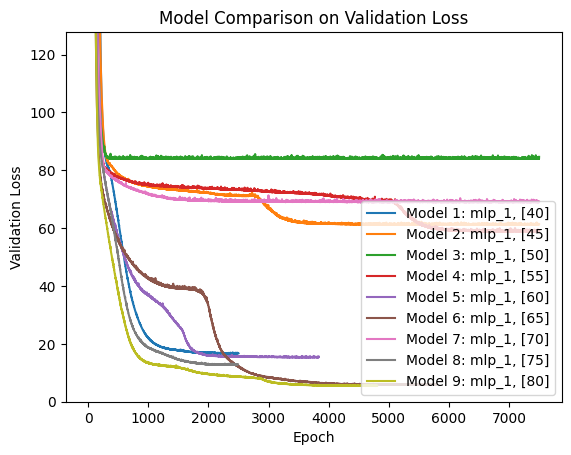

In [6]:
if write_flag:
    models_folder = f"{results_folder}/models_{dt}"
    if not os.path.exists(models_folder): os.makedirs(models_folder)
for data_size in data_size_range:
    if data_size != 1:
        # x_train, _, y_train, _ = train_test_split(x, y, test_size=1-data_size, random_state=93216)
        x_split = int(len(x) * data_size)
        y_split = int(len(y) * data_size)
        assert(x_split == y_split)
        x_train = x[:x_split]
        y_train = y[:y_split]
    else: x_train, y_train = x, y
        
    # xyz_diff = min_max_scaler.fit_transform(np.array(xyz_diff))
    # x_train = min_max_scaler.fit_transform(x_train) # pos


    # ## Model Design & Selection
    models = []
    for h in h_range:
        # if rnn_flag: models =  [(rnn, [[(n, False)]*h], {'activation': ACTIVATION_FUN}) for n in n_range] # eg
        if rnn_flag: models =  [(SimpleRNN, [], {}) for n in n_range] # eg
        else: models =  [(mlp_1, [[n]*h], {'activation': ACTIVATION_FUN}) for n in n_range] # eg

    # Using the model builder
        builder = DNNModelBuilder(x_train, models)

        # print(f"Last model in step: {models[-1][1]}")
        # print(builder.models[-1].summary())

        # print(x_train.shape)
        if rnn_flag:
            x_train = x_train.reshape(1, x_train.shape[0], x_train.shape[1])
            y_train = y_train.reshape(1, y_train.shape[0], y_train.shape[1])
            builder.train(x_train, y_train, epochs=MAX_EPOCH, batch_size=BATCH_SIZE, patience=PATIENCE, validation_split=0)
        else:
            builder.train(x_train, y_train, epochs=MAX_EPOCH, batch_size=BATCH_SIZE, validation_split=test_split/(1 - test_split), patience=PATIENCE)
        # for i, model in enumerate(builder.architectures):
        #     print(f"Model {i+1}: {str(model[0]).split(' ')[1]}, {model[1][0]}")
        builder.compare_models(stack=False)
        # losses = builder.evaluate(x_test, y_test)
        # builder.save_models()

        pred = builder.predict(x_test)

        # print("Mean Lengths:", np.mean(y_test))
        for i, p in enumerate(pred):
            # plot_positions_comparison(np.array(y_test), np.array(p))
            pred_abs_norm_err = np.abs(np.linalg.norm(p - y_test, axis=1))
            pred_rel_mean_err = pred_abs_norm_err / np.mean(y_test) * 100
            pred_rel_norm_err = np.abs(np.linalg.norm(p - y_test, axis=1)) / np.abs(np.linalg.norm(y_test, axis=1)) * 100
            pred_rel_scale_err = pred_abs_norm_err / (np.max(y_test[:,0]) - np.min(y_test[:,0])) * 100
            print(f"\nArchitechture: {str(builder.architectures[i][0]).split(' ')[1]}, {builder.architectures[i][1][0]}")
            print(f"% of data: {data_size * 100:.2f}%")
            print(f"Mean Relative Error: {np.mean(pred_rel_norm_err):.3f}%")
            print(f"Max Relative Error: {max(pred_rel_norm_err):.3f}%")
            print(f"Mean Absolute Error: {np.mean(pred_abs_norm_err):.3f} mm")
            print(f"Max Absolute Error: {max(pred_abs_norm_err):.3f} mm")
            print(f"Mean Relative Error (Mean Length): {np.mean(pred_rel_mean_err):.3f} %")
            print(f"Max Relative Error (Mean Length): {max(pred_rel_mean_err):.3f} %")
            print(f"Mean Relative Error (Full-Scale): {np.mean(pred_rel_scale_err):.3f}%")
            print(f"Max Relative Error (Full-Scale): {max(pred_rel_scale_err):.3f}%")

            if write_flag:
                result_file.write(f"\n{str(builder.architectures[i][0]).split(' ')[1]}, {builder.architectures[i][1][0]}; ")
                result_file.write(f"{data_size*100:.2f}; ")
                if builder.early_stopping == None or builder.early_stopping.stopped_epoch == None or builder.early_stopping.stopped_epoch == 0:
                    result_file.write(f"{MAX_EPOCH}; ")
                else: result_file.write(f"{len(builder.histories[i].history['val_loss'])}; ")

                result_file.write(f"{builder.histories[i].history['val_loss'][-1]:3f}; ")
                
                result_file.write(f"{np.mean(pred_rel_norm_err):.3f}; ")
                result_file.write(f"{max(pred_rel_norm_err):.3f}; ")
                result_file.write(f"{np.mean(pred_abs_norm_err):.3f}; ")
                result_file.write(f"{max(pred_abs_norm_err):.3f}; ")
                
                result_file.write(f"{np.std(pred_abs_norm_err):.3f}; ")
                result_file.write(f"{np.mean(y_test):3f}; ")
                result_file.write(f"{np.max(y_test[:,0]) - np.min(y_test[:,0]):3f}")
                
                # result_file.write(f"{np.mean(pred_rel_mean_err):.3f}; ")
                # result_file.write(f"{max(pred_rel_mean_err):.3f}; ")
                # result_file.write(f"{np.mean(pred_rel_scale_err):.3f}; ")
                # result_file.write(f"{max(pred_rel_scale_err):.3f}")
                

            builder.save_models(prefix=f"{str(builder.architectures[0][0]).split()[1]}_{int(data_size*100)}pct_{h}L", folder=models_folder)

            if not os.path.exists(f"{models_folder}/imgs/"): os.makedirs(f"{models_folder}/imgs/")
        
            if write_flag and data_size in [0.25, 0.5, 0.75, 1]: plt.savefig(f"{models_folder}/imgs/{str(builder.architectures[0][0]).split()[1]}_{int(data_size*100)}pct_{h}L.png")
            # if write_flag and data_size in [0.25, 0.5, 1]: plt.savefig(f'./results/final_datasets2/imgs/training_{data_size*100:.0f}_{h}L_{dt}.png')
        
        if write_flag: result_file.flush()

if write_flag: result_file.close()
plt.show()


In [7]:
# if not os.path.exists(f"{folder}/imgs/"): os.makedirs(f"{folder}/imgs/")

# plt.savefig(f"{folder}/imgs/{str(builder.architectures[0][0]).split()[1]}_{int(data_size*100)}pct_{h}L.png")

# result_file.flush()

# result_file.close()
# import os

# os.fsync(result_file)

In [ ]:
retest_flag = False
# retest_flag = True

if retest_flag:
    from keras.models import load_model
    import os
    # models_folder = "./results/final_datasets3/models_2024-04-13T100152"
    date = models_folder.split('_')[-1]
    print(date)
    # models = [(model_file, load_model(os.path.join(models_folder, model_file))) for model_file in os.listdir(models_folder) ]

    result_filepath = [file for file in os.listdir('/'.join(models_folder.split('/')[:-1])) if date in file and file.endswith(".txt")][0]
    result_filepath = os.path.join('/'.join(models_folder.split('/')[:-1]), result_filepath).replace('\\','/')
    # print(result_filepath)
    with open(result_filepath, 'a') as result_file:
        for model_file in [file for file in os.listdir(models_folder) if file.endswith(".keras")]:
            model = load_model(os.path.join(models_folder, model_file))
            p = model.predict(x_test)
            pred_abs_norm_err = np.abs(np.linalg.norm(p - y_test, axis=1))
            pred_rel_mean_err = pred_abs_norm_err / np.mean(y_test) * 100
            pred_rel_norm_err = np.abs(np.linalg.norm(p - y_test, axis=1)) / np.abs(np.linalg.norm(y_test, axis=1)) * 100
            pred_rel_scale_err = pred_abs_norm_err / (np.max(y_test[:,0]) - np.min(y_test[:,0])) * 100

            model_props = model_file.split('.', 1)[0].split('_')
            # print(model_props)
            # print(f"\nmlp_1, {[int(model_props[-1])] * int(model_props[-2][:-1])}; ")
            # pct = ''.join([char for char in model_props[-3] if char.isdigit()])
            # print(float('0.' + model_props[-3][:-3]))
            # print(f"{min(data_size_range, key=lambda x: abs(x - float('0.' + model_props[-3][:-3])))*100:.2f}; ")
            # print(f"{np.nan}; ")
            # print(f"{np.nan}")
            if model_file.startswith("mlp_1"):
                result_file.write(f"\nmlp_1, {[int(model_props[-1])] * int(model_props[-2][:-1])}; ")
            elif model_file.startswith("rnn"):
                result_file.write(f"\nrnn, {[int(model_props[-1])] * int(model_props[-2][:-1])}; ")

            result_file.write(f"{min(data_size_range, key=lambda x: abs(x - float('0.' + model_props[-3][:-3])))*100:.2f}; ")
            result_file.write(f"{np.nan}; ")
            # result_file.write(f"{data_size*100:.2f}; ")
            # if builder.early_stopping == None or builder.early_stopping.stopped_epoch == None or builder.early_stopping.stopped_epoch == 0:
            #     result_file.write(f"{MAX_EPOCH}; ")
            # else: result_file.write(f"{len(builder.histories[i].history['val_loss'])}; ")

            result_file.write(f"{np.nan}; ")
            # result_file.write(f"{builder.histories[i].history['val_loss'][-1]:3f}; ")
            
            result_file.write(f"{np.mean(pred_rel_norm_err):.3f}; ")
            result_file.write(f"{max(pred_rel_norm_err):.3f}; ")
            result_file.write(f"{np.mean(pred_abs_norm_err):.3f}; ")
            result_file.write(f"{max(pred_abs_norm_err):.3f}; ")
            
            result_file.write(f"{np.std(pred_abs_norm_err):.3f}; ")
            result_file.write(f"{np.mean(y_test):3f}; ")
            result_file.write(f"{np.max(y_test[:,0]) - np.min(y_test[:,0]):3f}")
    